In [ ]:
## Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
## Load Data

customers = pd.read_csv(r"C:\Users\pandy\OneDrive\Desktop\Github\Retail_Sales_Performance_Analysis\data\customers.csv")
products = pd.read_csv(r"C:\Users\pandy\OneDrive\Desktop\Github\Retail_Sales_Performance_Analysis\data\products.csv")
sales = pd.read_csv(r"C:\Users\pandy\OneDrive\Desktop\Github\Retail_Sales_Performance_Analysis\data\sales.csv")


In [ ]:
## Merge Tables

df = sales.merge(customers, on="customer_id").merge(products, on="product_id")
df

,sale_id,customer_id,product_id,quantity,discount,sale_date,customer_name,region,signup_date,product_name,category,unit_price,cost_price
0,1,10475,2301,1,0.05,18-01-2022,Customer_10475,North,25-10-2021,Product_2301,Grocery,148.61,88.39
1,2,1662,1692,3,0.19,27-06-2021,Customer_1662,South,28-12-2022,Product_1692,Grocery,260.26,154.79
2,3,15388,3304,1,0.08,23-07-2023,Customer_15388,East,28-11-2020,Product_3304,Sports,419.97,249.78
3,4,476,1492,4,0.08,16-08-2023,Customer_476,North,23-10-2022,Product_1492,Sports,428.54,254.88
4,5,11325,3377,4,0.03,01-10-2023,Customer_11325,North,24-01-2018,Product_3377,Clothing,234.44,139.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...
119995,119996,12363,2219,5,0.09,17-09-2021,Customer_12363,North,01-01-2018,Product_2219,Sports,140.35,83.48
119996,119997,10329,2389,4,0.21,02-01-2023,Customer_10329,East,30-06-2019,Product_2389,Furniture,202.00,120.14
119997,119998,17938,921,4,0.02,01-05-2021,Customer_17938,South,09-05-2023,Product_921,Grocery,170.14,101.19
119998,119999,19735,1369,5,0.02,19-05-2021,Customer_19735,South,20-06-2019,Product_1369,Sports,146.13,86.91


In [ ]:
## Add Calculated Columns

df["revenue"] = df["quantity"] * df["unit_price"] * (1 - df["discount"])
df["profit"] = df["quantity"] * (df["unit_price"] - df["cost_price"])
df["month"] = pd.to_datetime(df["sale_date"]).dt.to_period("M")
df

C:\Users\pandy\AppData\Local\Temp\ipykernel_69016\3758534383.py:5: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["month"] = pd.to_datetime(df["sale_date"]).dt.to_period("M")


,sale_id,customer_id,product_id,quantity,discount,sale_date,customer_name,region,signup_date,product_name,category,unit_price,cost_price,revenue,profit,month
0,1,10475,2301,1,0.05,18-01-2022,Customer_10475,North,25-10-2021,Product_2301,Grocery,148.61,88.39,141.1795,60.22,2022-01
1,2,1662,1692,3,0.19,27-06-2021,Customer_1662,South,28-12-2022,Product_1692,Grocery,260.26,154.79,632.4318,316.41,2021-06
2,3,15388,3304,1,0.08,23-07-2023,Customer_15388,East,28-11-2020,Product_3304,Sports,419.97,249.78,386.3724,170.19,2023-07
3,4,476,1492,4,0.08,16-08-2023,Customer_476,North,23-10-2022,Product_1492,Sports,428.54,254.88,1577.0272,694.64,2023-08
4,5,11325,3377,4,0.03,01-10-2023,Customer_11325,North,24-01-2018,Product_3377,Clothing,234.44,139.44,909.6272,380.00,2023-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119995,119996,12363,2219,5,0.09,17-09-2021,Customer_12363,North,01-01-2018,Product_2219,Sports,140.35,83.48,638.5925,284.35,2021-09
119996,119997,10329,2389,4,0.21,02-01-2023,Customer_10329,East,30-06-2019,Product_2389,Furniture,202.00,120.14,638.3200,327.44,2023-01
119997,119998,17938,921,4,0.02,01-05-2021,Customer_17938,South,09-05-2023,Product_921,Grocery,170.14,101.19,666.9488,275.80,2021-05
119998,119999,19735,1369,5,0.02,19-05-2021,Customer_19735,South,20-06-2019,Product_1369,Sports,146.13,86.91,716.0370,296.10,2021-05


# EDA

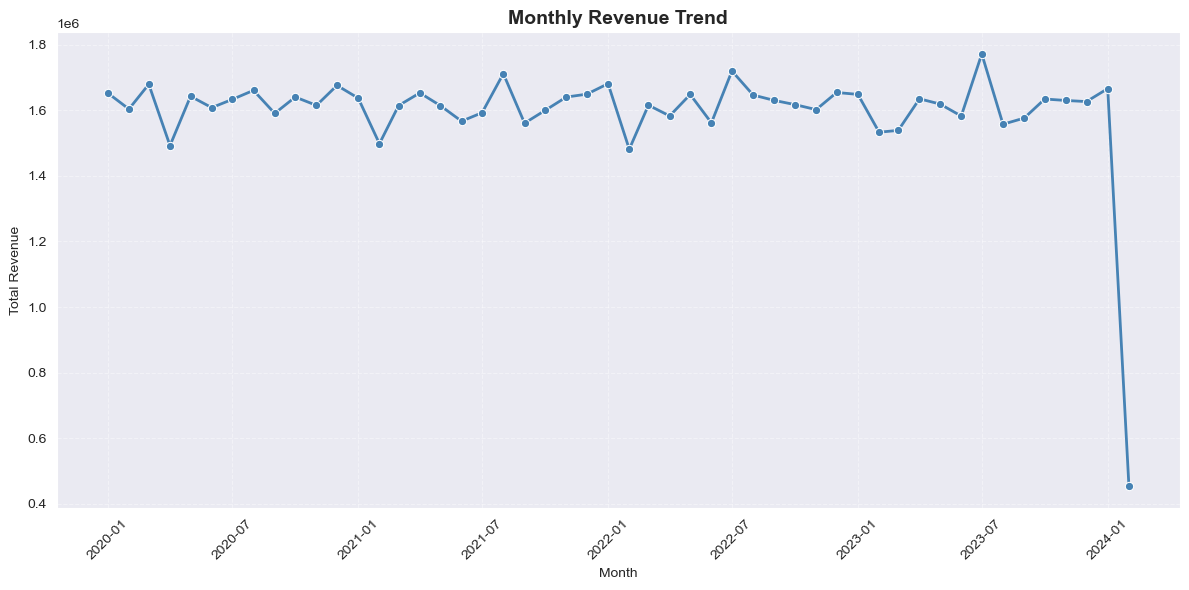

In [ ]:
## Monthly Sales Trend

monthly_sales = (
    df.groupby("month", as_index=False)["revenue"]
    .sum()
)
monthly_sales["month"] = monthly_sales["month"].dt.to_timestamp()

# Ensure correct data types
monthly_sales["month"] = pd.to_datetime(monthly_sales["month"])
monthly_sales["revenue"] = pd.to_numeric(monthly_sales["revenue"])

# Sort data by time
monthly_sales = monthly_sales.sort_values("month")

# Create figure
plt.figure(figsize=(12, 6))

# Line plot
sns.lineplot(
    data=monthly_sales,
    x="month",
    y="revenue",
    marker="o",
    linewidth=2,
    color="steelblue"
)

# Titles and labels
plt.title("Monthly Revenue Trend", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

# Rotate x-axis labels
plt.xticks(rotation=45)

# Grid for readability
plt.grid(True, linestyle="--", alpha=0.4)

# Adjust layout and show plot
plt.tight_layout()
plt.savefig(
    r"C:\Users\pandy\OneDrive\Desktop\Github\Retail_Sales_Performance_Analysis\python\visualizations\monthly_revenue_trend.png",  # File name or path
    dpi=300,  # High resolution for print/presentations
    bbox_inches="tight",  # Prevents labels/legends from getting cut off
)
plt.show()

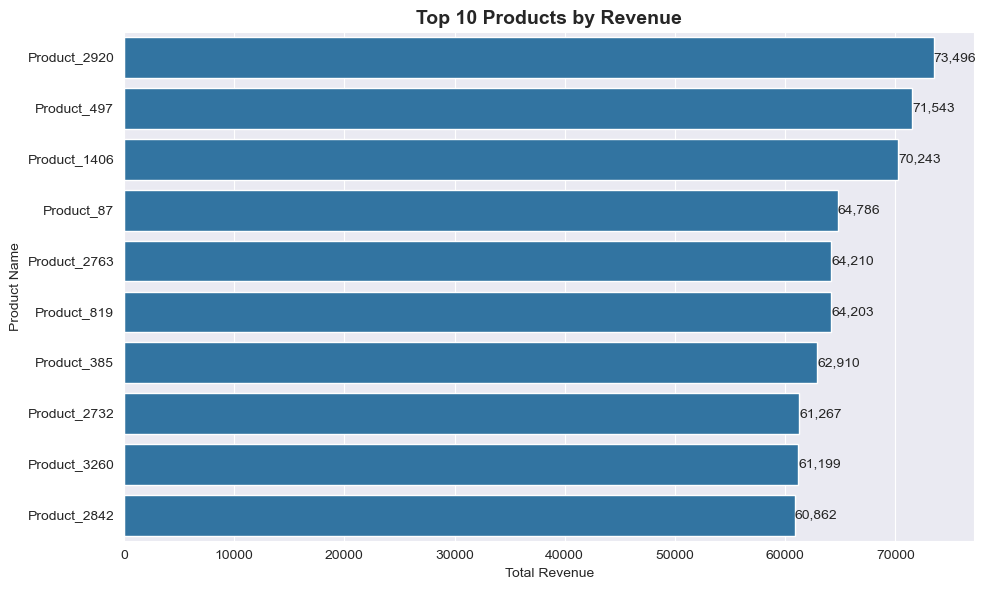

In [ ]:
## Top 10 Products By Revenue

# Aggregate revenue by product
top_products = (
    df.groupby("product_name", as_index=False)["revenue"]
    .sum()
)

# Select Top 10 products
top_10_products = (
    top_products
    .sort_values("revenue", ascending=False)
    .head(10)
)

# Create figure
plt.figure(figsize=(10, 6))

# Plot horizontal bar chart
sns.barplot(
    data=top_10_products,
    x="revenue",
    y="product_name"
)

# Titles and labels
plt.title("Top 10 Products by Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Total Revenue")
plt.ylabel("Product Name")

# Add value labels
for index, value in enumerate(top_10_products["revenue"]):
    plt.text(
        value,
        index,
        f"{value:,.0f}",
        va="center",
        ha="left"
    )

# Display plot
plt.tight_layout()
plt.savefig(
    r"C:\Users\pandy\OneDrive\Desktop\Github\Retail_Sales_Performance_Analysis\python\visualizations\top_10_products_by_revenue.png",  # File name or path
    dpi=300,  # High resolution for print/presentations
    bbox_inches="tight",  # Prevents labels/legends from getting cut off
)
plt.show()

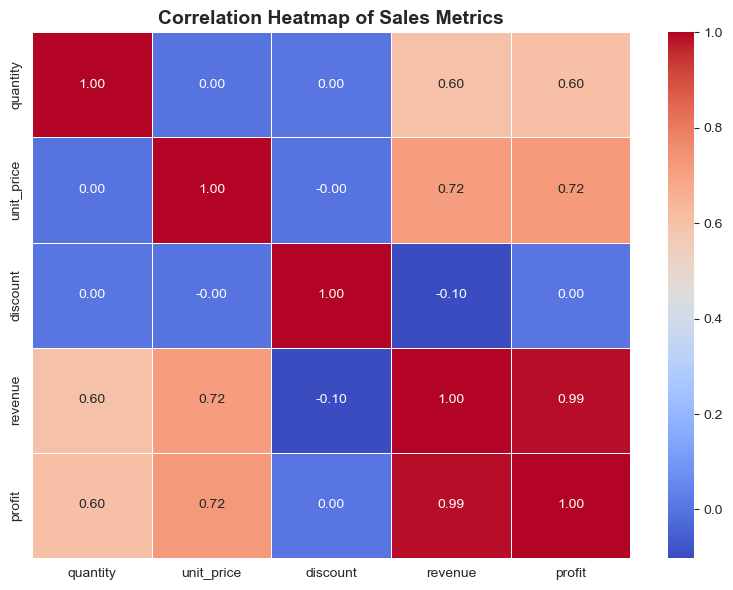

In [ ]:
## Correlational Heatmap

# Select relevant numeric columns
corr_data = df[
    ["quantity", "unit_price", "discount", "revenue", "profit"]
]

# Remove missing values
corr_data = corr_data.dropna()

# Compute correlation matrix
correlation_matrix = corr_data.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

# Title and display
plt.title("Correlation Heatmap of Sales Metrics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(
    r"C:\Users\pandy\OneDrive\Desktop\Github\Retail_Sales_Performance_Analysis\python\visualizations\correlational_heatmap.png",  # File name or path
    dpi=300,  # High resolution for print/presentations
    bbox_inches="tight",  # Prevents labels/legends from getting cut off
)
plt.show()

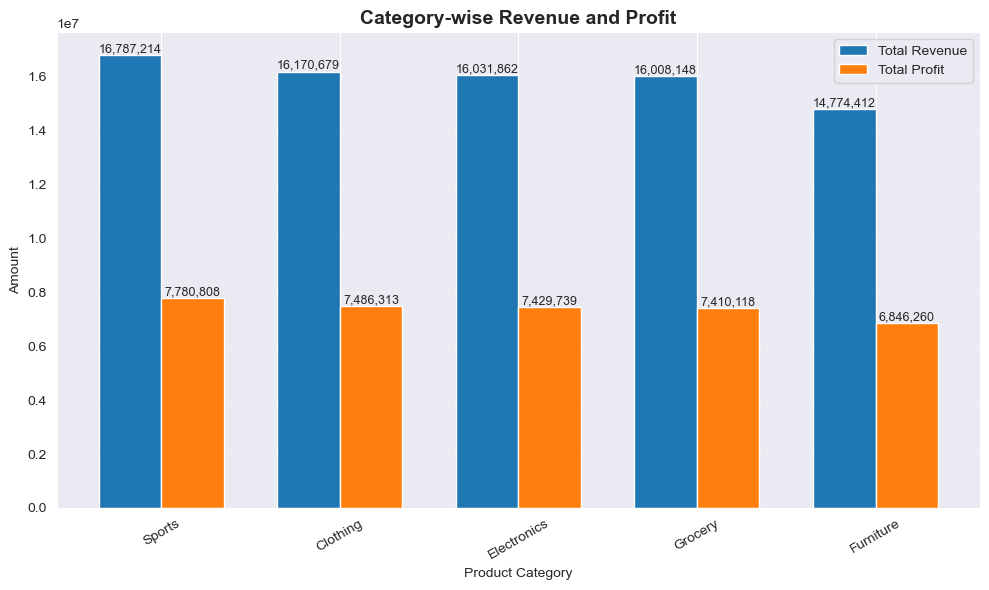

In [ ]:
## Category-wise Revenue and Profit

# Aggregate by category
category_summary = (
    df.groupby("category", as_index=False)
      .agg(
          total_revenue=("revenue", "sum"),
          total_profit=("profit", "sum")
      )
)

# Sort by revenue
category_summary = category_summary.sort_values("total_revenue", ascending=False)

# Plot
x = np.arange(len(category_summary))
width = 0.35

plt.figure(figsize=(10, 6))

revenue_bars = plt.bar(x - width/2, category_summary["total_revenue"], width, label="Total Revenue")
profit_bars = plt.bar(x + width/2, category_summary["total_profit"], width, label="Total Profit")

plt.xticks(x, category_summary["category"], rotation=30)
plt.title("Category-wise Revenue and Profit", fontsize=14, fontweight="bold")
plt.xlabel("Product Category")
plt.ylabel("Amount")
plt.legend()
plt.grid(True, axis="y", linestyle="--", alpha=0.3)

# Annotations
for bar in revenue_bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )
for bar in profit_bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# Display plot
plt.tight_layout()
plt.savefig(
    r"C:\Users\pandy\OneDrive\Desktop\Github\Retail_Sales_Performance_Analysis\python\visualizations\category-wise_revenue_and_profit.png",  # File name or path
    dpi=300,  # High resolution for print/presentations
    bbox_inches="tight",  # Prevents labels/legends from getting cut off
)
plt.show()

C:\Users\pandy\AppData\Local\Temp\ipykernel_69016\3813233564.py:4: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["sale_date"] = pd.to_datetime(df["sale_date"])


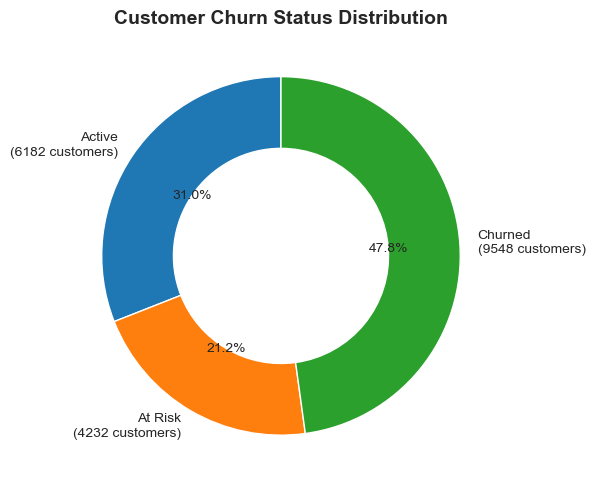

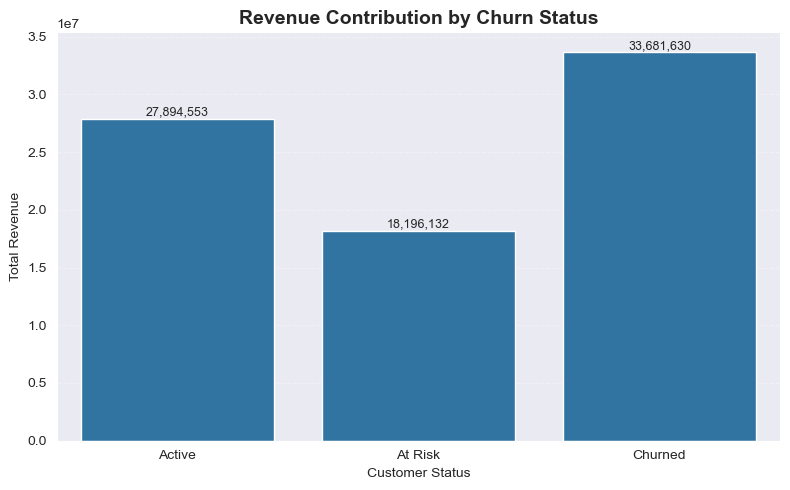

In [ ]:
## Customer Churn Status Distribution and Revenue Contribution by Churn Status

# Convert date
df["sale_date"] = pd.to_datetime(df["sale_date"])

# Step 3: Last purchase per customer
customer_last_purchase = (
    df.groupby("customer_id", as_index=False)
      .agg(
          last_purchase_date=("sale_date", "max"),
          total_revenue=("revenue", "sum")
      )
)

# Days since last purchase
analysis_date = df["sale_date"].max()

customer_last_purchase["days_since_last_purchase"] = (
    analysis_date - customer_last_purchase["last_purchase_date"]
).dt.days

# Churn classification
def churn_label(days):
    if days <= 90:
        return "Active"
    elif days <= 180:
        return "At Risk"
    else:
        return "Churned"

customer_last_purchase["churn_status"] = (
    customer_last_purchase["days_since_last_purchase"]
    .apply(churn_label)
)

# Summary
churn_summary = (
    customer_last_purchase
    .groupby("churn_status", as_index=False)
    .agg(
        customers=("customer_id", "count"),
        total_revenue=("total_revenue", "sum")
    )
)

# Donut chart
plt.figure(figsize=(6, 6))
plt.pie(
    churn_summary["customers"],
    labels=[
        f"{status}\n({count} customers)"
        for status, count in zip(
            churn_summary["churn_status"],
            churn_summary["customers"]
        )
    ],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)
)
plt.title("Customer Churn Status Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(
    r"C:\Users\pandy\OneDrive\Desktop\Github\Retail_Sales_Performance_Analysis\python\visualizations\customer_churn_status_distribution.png",  # File name or path
    dpi=300,  # High resolution for print/presentations
    bbox_inches="tight",  # Prevents labels/legends from getting cut off
)
plt.show()

# Revenue impact
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=churn_summary,
    x="churn_status",
    y="total_revenue"
)
plt.title("Revenue Contribution by Churn Status", fontsize=14, fontweight="bold")
plt.xlabel("Customer Status")
plt.ylabel("Total Revenue")
plt.grid(True, axis="y", linestyle="--", alpha=0.3)


# ADD REVENUE ANNOTATIONS
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(
    r"C:\Users\pandy\OneDrive\Desktop\Github\Retail_Sales_Performance_Analysis\python\visualizations\revenue_contribution_by_churn_status.png",  # File name or path
    dpi=300,  # High resolution for print/presentations
    bbox_inches="tight",  # Prevents labels/legends from getting cut off
)
plt.show()

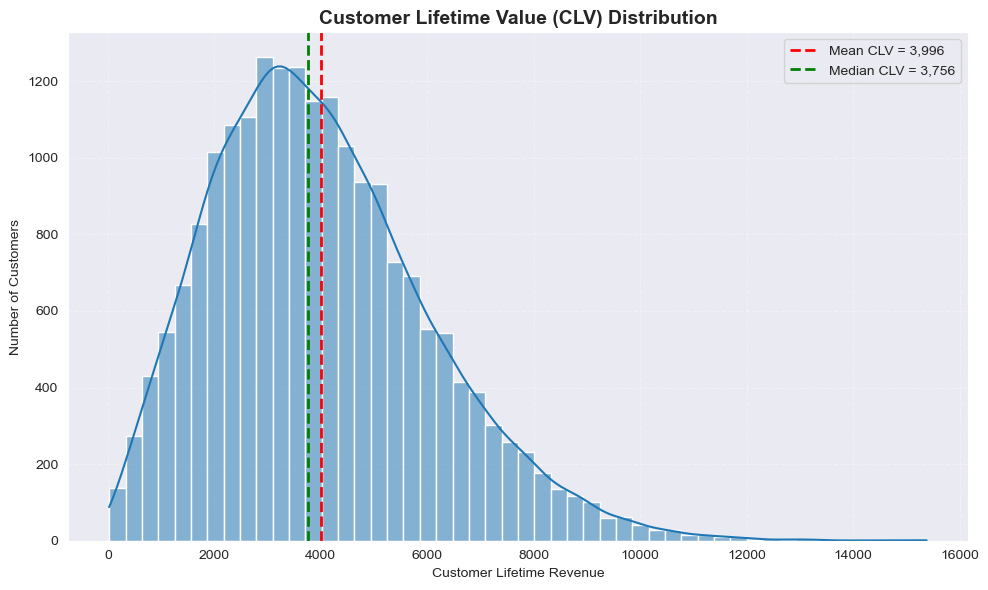

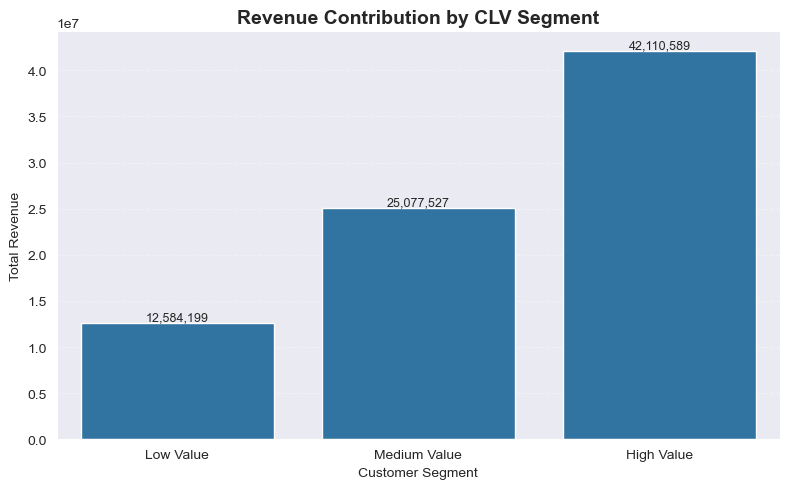

In [ ]:
## CLV Distribution and Revenue Contribution by CLV Segment

# Calculate CLV per customer
customer_clv = (
    df.groupby("customer_id", as_index=False)
      .agg(
          total_revenue=("revenue", "sum"),
          total_orders=("revenue", "count")
      )
)

# CLV distribution
plt.figure(figsize=(10, 6))
sns.histplot(customer_clv["total_revenue"], bins=50, kde=True)
plt.title("Customer Lifetime Value (CLV) Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Customer Lifetime Revenue")
plt.ylabel("Number of Customers")
plt.grid(True, linestyle="--", alpha=0.3)

# Calculate statistics
mean_clv = customer_clv["total_revenue"].mean()
median_clv = customer_clv["total_revenue"].median()

# Add vertical lines
plt.axvline(mean_clv, color="red", linestyle="--", linewidth=2, label=f"Mean CLV = {mean_clv:,.0f}")
plt.axvline(median_clv, color="green", linestyle="--", linewidth=2, label=f"Median CLV = {median_clv:,.0f}")

plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig(
    r"C:\Users\pandy\OneDrive\Desktop\Github\Retail_Sales_Performance_Analysis\python\visualizations\clv_distribution.png",  # File name or path
    dpi=300,  # High resolution for print/presentations
    bbox_inches="tight",  # Prevents labels/legends from getting cut off
)
plt.show()

# CLV Segmentation
customer_clv["clv_segment"] = pd.qcut(
    customer_clv["total_revenue"],
    q=3,
    labels=["Low Value", "Medium Value", "High Value"]
)

# Revenue by CLV segment
clv_summary = (
    customer_clv.groupby("clv_segment", observed=True, as_index=False)
                .agg(
                    customers=("customer_id", "count"),
                    total_revenue=("total_revenue", "sum")
                )
)

# Plot CLV segment contribution
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=clv_summary,
    x="clv_segment",
    y="total_revenue"
)

# ADD ANNOTATIONS ON BARS
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Revenue Contribution by CLV Segment", fontsize=14, fontweight="bold")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")
plt.grid(True, axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(
    r"C:\Users\pandy\OneDrive\Desktop\Github\Retail_Sales_Performance_Analysis\python\visualizations\revenue_contribution_by_clv_segment.png",  # File name or path
    dpi=300,  # High resolution for print/presentations
    bbox_inches="tight",  # Prevents labels/legends from getting cut off
)
plt.show()

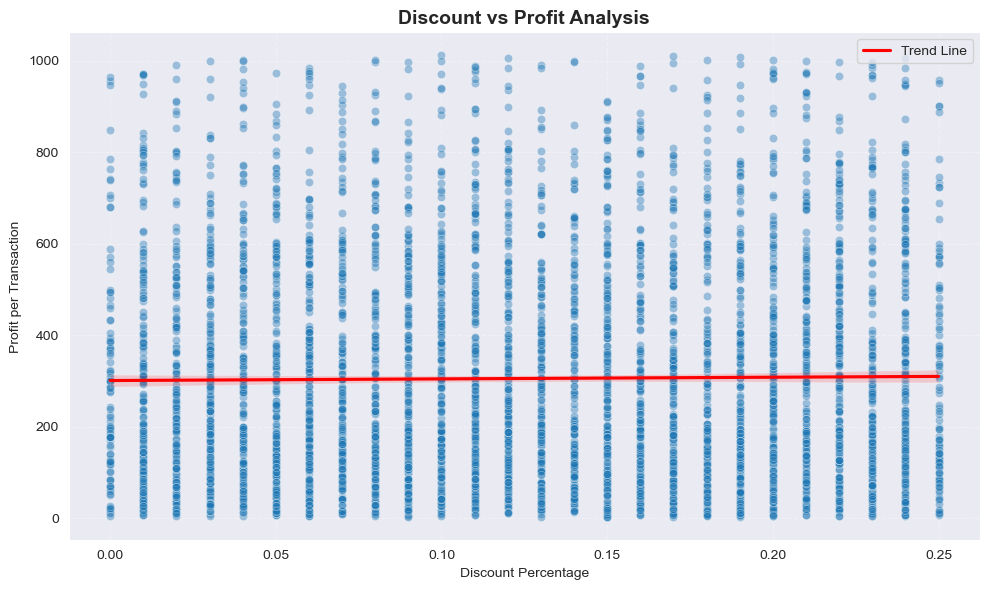

In [ ]:
## Discount vs Profit Analysis

# Select required columns
scatter_data = df[["discount", "profit"]].dropna()

# Sample data
scatter_sample = scatter_data.sample(5000, random_state=42)

# Plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=scatter_sample,
    x="discount",
    y="profit",
    alpha=0.4
)

# Trend line
sns.regplot(
    data=scatter_sample,
    x="discount",
    y="profit",
    scatter=False,
    color="red",
    label="Trend Line"
)

# Formatting
plt.title("Discount vs Profit Analysis", fontsize=14, fontweight="bold")
plt.xlabel("Discount Percentage")
plt.ylabel("Profit per Transaction")
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig(
    r"C:\Users\pandy\OneDrive\Desktop\Github\Retail_Sales_Performance_Analysis\python\visualizations\discount_vs_profit_analysis.png",  # File name or path
    dpi=300,  # High resolution for print/presentations
    bbox_inches="tight",  # Prevents labels/legends from getting cut off
)
plt.show()

# Simple Forecast

In [ ]:
monthly = df.groupby("month")["revenue"].sum()
monthly.index = monthly.index.to_timestamp()

from statsmodels.tsa.api import SimpleExpSmoothing

model = SimpleExpSmoothing(monthly).fit()
forecast = model.forecast(6)

# Print the forecast
print(forecast)

# Display it properly
forecast_df = forecast.reset_index()
forecast_df.columns = ["month", "forecasted_revenue"]
forecast_df

2024-03-01    1.546304e+06
2024-04-01    1.546304e+06
2024-05-01    1.546304e+06
2024-06-01    1.546304e+06
2024-07-01    1.546304e+06
2024-08-01    1.546304e+06
Freq: MS, dtype: float64


,month,forecasted_revenue
0,2024-03-01,1.546304e+06
1,2024-04-01,1.546304e+06
2,2024-05-01,1.546304e+06
3,2024-06-01,1.546304e+06
4,2024-07-01,1.546304e+06
5,2024-08-01,1.546304e+06


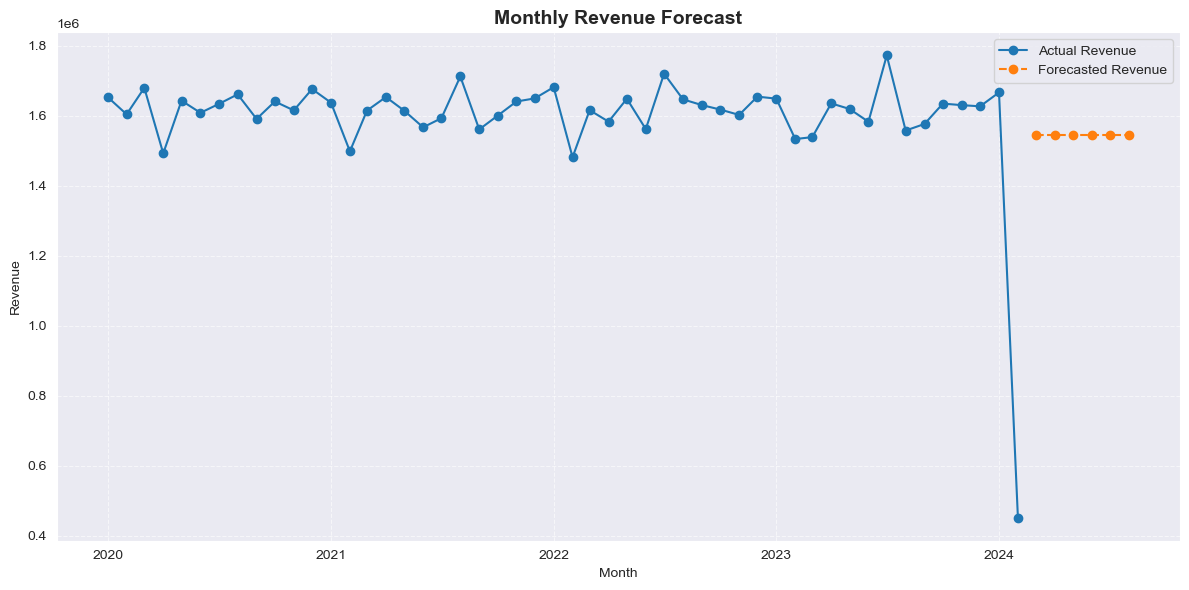

In [ ]:
# Ensure indexes are datetime
forecast.index = pd.to_datetime(forecast.index)

# Create figure
plt.figure(figsize=(12, 6))

# Plot actual revenue
plt.plot(
    monthly.index,
    monthly.values,
    label="Actual Revenue",
    marker="o"
)

# Plot forecasted revenue
plt.plot(
    forecast.index,
    forecast.values,
    label="Forecasted Revenue",
    linestyle="--",
    marker="o"
)

# Formatting
plt.legend()
plt.title("Monthly Revenue Forecast", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True, linestyle="--", alpha=0.6)

# Display
plt.tight_layout()
plt.savefig(
    r"C:\Users\pandy\OneDrive\Desktop\Github\Retail_Sales_Performance_Analysis\python\visualizations\monthly_revenue_forecast.png",  # File name or path
    dpi=300,  # High resolution for print/presentations
    bbox_inches="tight",  # Prevents labels/legends from getting cut off
)
plt.show()